In [115]:
%matplotlib inline

import numpy as np
import scipy
import matplotlib.pyplot as plt

from pyiga import bspline, assemble, geometry, vis

In [118]:
# define geometry
geo = geometry.unit_square()#.translate((0.1,0.1))

# define discretization space
deg = 3    # spline degree
kvs = 2 * (bspline.make_knots(deg, 0.0, 1.0, 5),)

# define parameters
p = 2.2
eps=1e-8 #regularization 

u_exact=lambda x,y: np.exp(x**2+y**2)
f=lambda x,y: -np.exp((p-1)*(x**2+y**2))*(2**p*(p-1)*(x**2+y**2)**(p/2)+2**(p-1)*p*(x**2+y**2)**((p-2)/2))

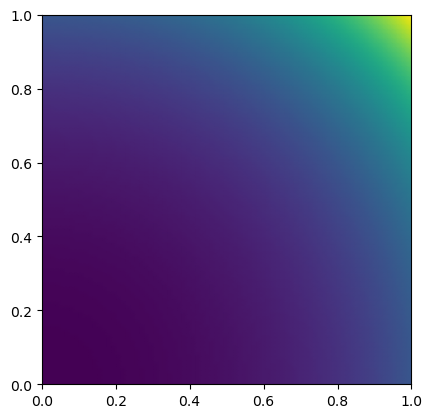

In [113]:
A = assemble.assemble('inner(grad(u),grad(v)) * dx', kvs, geo=geo)
F = assemble.assemble('f * v * dx',kvs, geo=geo, f=f, physical=True).ravel()
bcs = assemble.compute_dirichlet_bcs(kvs, geo, [('bottom',u_exact),('right',u_exact),('left', u_exact), ('top', u_exact)])
LS = assemble.RestrictedLinearSystem(A,F,bcs=bcs)
u = scipy.sparse.linalg.spsolve(LS.A, LS.b)
u = LS.complete(u)

u_func = geometry.BSplineFunc(kvs, u)
vis.plot_field(u_exact, geo, physical=1)
plt.axis('scaled');

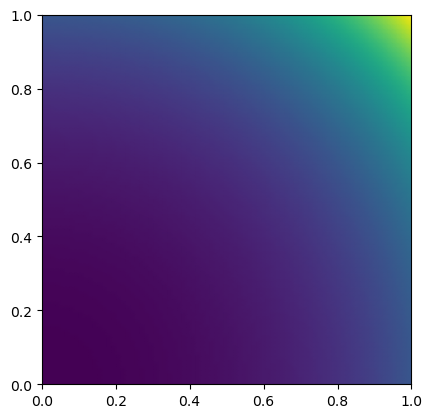

In [114]:
bcs0 = assemble.compute_dirichlet_bcs(kvs, geo, [('bottom',0),('right',0),('left', 0), ('top', 0)])
for i in range(100):
    w = geometry.BSplineFunc(kvs, u)
    A = assemble.assemble('( (inner(grad(w),grad(w)) + eps**2) ** ((p-2)/2) * inner(grad(u),grad(v)) + (p-2) * (inner(grad(w),grad(w)) + eps**2) ** ((p-4)/2) * inner(grad(u),grad(w)) * inner(grad(v),grad(w))) * dx', kvs, bfuns=[('u',1),('v',1)], geo=geo, p=p, w=w, eps=eps)
    F = assemble.assemble('((inner(grad(w),grad(w)) + eps**2) ** ((p-2)/2) * inner(grad(w),grad(v)) - f*v)* dx',kvs, bfuns=[('v',1)],geo=geo, p=p, w=w, eps=eps, f=f).ravel()
    LS = assemble.RestrictedLinearSystem(A,F,bcs=bcs0)
    u_delta = scipy.sparse.linalg.spsolve(LS.A, -LS.b)
    u_delta = LS.complete(u_delta)
    u += u_delta
vis.plot_field(geometry.BSplineFunc(kvs, u),geo)
plt.axis('scaled');